In [1]:
import pandas as pd
import warnings

# Ignore warnings
warnings.filterwarnings('ignore')

# Load the data
data = pd.read_csv('new_dataset.csv')

# Count the number of rows in the data frame
num_rows = len(data)

# Display this count
print("Number of rows in the dataset: {}".format(num_rows))

# Information about the data frame
data.info()

# Display the first few rows of the data frame, sorted by the crash date in ascending order
data.sort_values(by='CRASH DATE').head().set_index('CRASH DATE')

Number of rows in the dataset: 2124643
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2124643 entries, 0 to 2124642
Data columns (total 10 columns):
 #   Column                         Dtype  
---  ------                         -----  
 0   CRASH DATE                     object 
 1   CRASH TIME                     object 
 2   NUMBER OF PERSONS INJURED      float64
 3   NUMBER OF PERSONS KILLED       float64
 4   NUMBER OF PEDESTRIANS INJURED  int64  
 5   NUMBER OF PEDESTRIANS KILLED   int64  
 6   NUMBER OF CYCLIST INJURED      int64  
 7   NUMBER OF CYCLIST KILLED       int64  
 8   NUMBER OF MOTORIST INJURED     int64  
 9   NUMBER OF MOTORIST KILLED      int64  
dtypes: float64(2), int64(6), object(2)
memory usage: 162.1+ MB


,CRASH TIME,NUMBER OF PERSONS INJURED,NUMBER OF PERSONS KILLED,NUMBER OF PEDESTRIANS INJURED,NUMBER OF PEDESTRIANS KILLED,NUMBER OF CYCLIST INJURED,NUMBER OF CYCLIST KILLED,NUMBER OF MOTORIST INJURED,NUMBER OF MOTORIST KILLED
CRASH DATE,,,,,,,,,
01/01/2013,22:07,0.0,0.0,0,0,0,0,0,0
01/01/2013,9:00,2.0,0.0,0,0,0,0,2,0
01/01/2013,17:50,1.0,0.0,0,0,0,0,1,0
01/01/2013,4:00,0.0,0.0,0,0,0,0,0,0
01/01/2013,5:20,1.0,0.0,0,0,0,0,1,0


In [2]:
# Convert 'CRASH DATE' and 'CRASH TIME' columns to datetime
data['CRASH DATE'] = pd.to_datetime(data['CRASH DATE'], errors='coerce')
data['CRASH TIME'] = pd.to_datetime(data['CRASH TIME'], format='%H:%M', errors='coerce').dt.time

# Define time intervals based on daily activities
time_intervals = {
    'Early Morning': (0, 5),
    'Morning': (5, 9),
    'School Hours': (7, 16),
    'Office Hours': (9, 17),
    'Afternoon': (15, 19),
    'Evening': (19, 24)
}

# Categorize each crash time into the defined intervals
def categorize_time(hour):
    for interval, (start, end) in time_intervals.items():
        if start <= hour < end:
            return interval
    return None

# Extract hour from CRASH TIME and apply categorization
data['Time Interval'] = data['CRASH TIME'].apply(lambda x: categorize_time(x.hour) if x else None)

# Group by 'Time Interval' and calculate total injuries and fatalities
time_interval_stats = data.groupby('Time Interval')[['NUMBER OF PERSONS INJURED', 'NUMBER OF PERSONS KILLED']].sum()

# Rename columns for clarity
time_interval_stats.columns = ['Injured', 'Killed']

# Convert Injured and Killed columns to integers
time_interval_stats = time_interval_stats.astype(int)

# Display the statistics as a data frame
time_interval_stats.sort_values(by='Injured', ascending=False)


,Injured,Killed
Time Interval,,
School Hours,229565,769
Evening,155486,825
Afternoon,90236,340
Morning,80284,450
Early Morning,72041,741
Office Hours,45134,123


Note that
1. School Hours shows the most counts of injuries.
   - Children are more likely to get injured on the road during school hours, on their way to school.
   - Maturity and experience are important factors to prevent injuries.
2. Next is Evening Hours.
   - Children are more likely to get injured on the road during evening hours, on their way home from school.
   - It is important to pay attention to children's safety during evening hours.
3. The number of injuries just before Evening Hours is also high.
   - This is when the sunlight starts getting weaker and the visibility is getting worse.
   - It is important to pay attention to children's safety during this time as well.
4. The number of injuries during the day is relatively low, especially during office hours, when compared to other times.
   - This is because there are fewer children on the road during this time.
   - It is important to pay attention to children's safety during school hours and evening hours.

In [3]:
time_interval_stats.sort_values(by='Killed', ascending=False)

,Injured,Killed
Time Interval,,
Evening,155486,825
School Hours,229565,769
Early Morning,72041,741
Morning,80284,450
Afternoon,90236,340
Office Hours,45134,123


Note that
1. The number of deaths is the highest during Evening Hours.
   - People are more likely to die on the road during evening hours, on their way home from work, school, or other activities.
2. The number of deaths is the second highest during School Hours.
    - People are more likely to die on the road during school hours, on their way to school.
3. The least number of deaths occur during office hours.
    - People are less likely to die on the road during office hours, due to their education and experience.

It is important to pay attention to safety during school hours and evening hours.

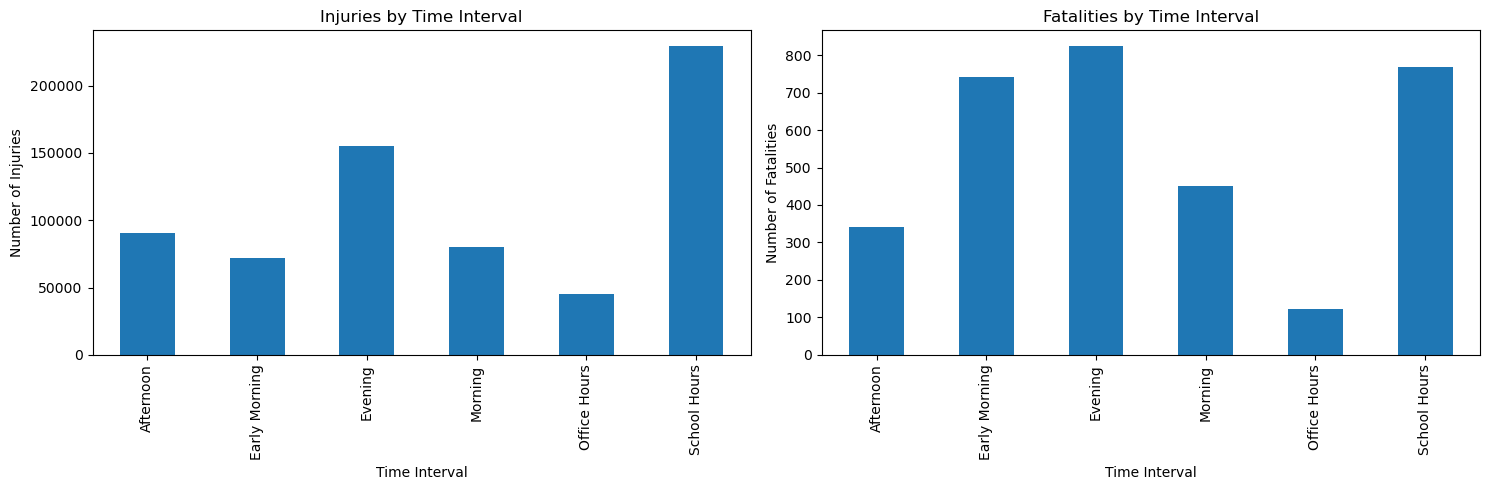

In [4]:
import matplotlib.pyplot as plt

# Create subplots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

# Draw a bar plot for Injured
time_interval_stats['Injured'].plot(kind='bar', ax=axes[0], stacked=True)
axes[0].set_title('Injuries by Time Interval')
axes[0].set_xlabel('Time Interval')
axes[0].set_ylabel('Number of Injuries')

# Draw a bar plot for Killed
time_interval_stats['Killed'].plot(kind='bar', ax=axes[1], stacked=True)
axes[1].set_title('Fatalities by Time Interval')
axes[1].set_xlabel('Time Interval')
axes[1].set_ylabel('Number of Fatalities')

# Adjust layout
plt.tight_layout()

# Save the plot as a PNG file and an EPS file
plt.savefig('images/time_interval_stats.png', format='png', dpi=220)
plt.savefig('images/time_interval_stats.eps', format='eps', dpi=220)


# Display the plot
plt.show()

In [5]:
# Find the number of injured people in the data frame by year as an integer
injured = data.groupby('CRASH DATE')['NUMBER OF PERSONS INJURED'].sum()

# Find the number of killed people in the data frame by year as an integer
killed = data.groupby('CRASH DATE')['NUMBER OF PERSONS KILLED'].sum()

# Display the number of injured and killed people by year in the data frame
df = pd.DataFrame({'Injured': injured.astype(int), 'Killed': killed.astype(int)})

# The first column should be replaced with the year of the crash date
df.index = pd.to_datetime(df.index).year

# Name the index column as 'Year'
df.index.name = 'Year'

# # If there are duplicate years, the values should be summed
df = df.groupby(df.index).sum()

# Display the first few rows of the updated data frame
df

,Injured,Killed
Year,,
2012,27453,137
2013,55128,297
2014,51226,262
2015,51358,243
2016,60317,246
2017,60656,256
2018,61941,231
2019,61390,244
2020,44614,269


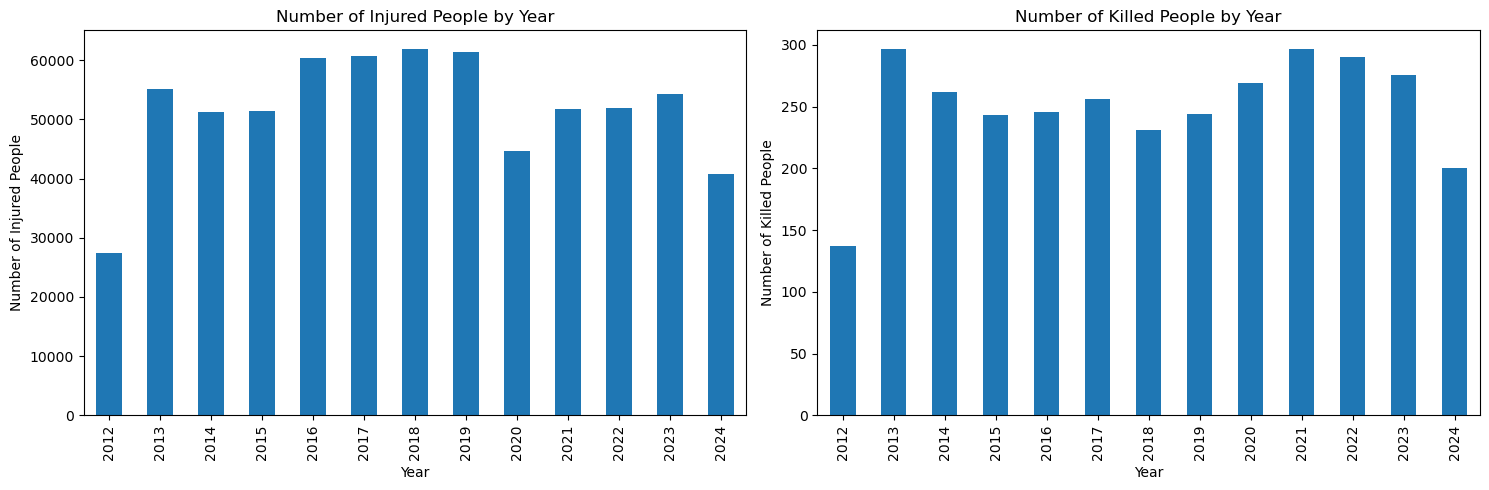

In [6]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

# Plot Injured
df['Injured'].plot(kind='bar', ax=axes[0], legend=False)
axes[0].set_title('Number of Injured People by Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Number of Injured People')

# Plot Killed
df['Killed'].plot(kind='bar', ax=axes[1], legend=False)
axes[1].set_title('Number of Killed People by Year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Number of Killed People')

# Adjust layout
plt.tight_layout()

# Save the plot as a PNG file and an EPS file
plt.savefig('images/injured_killed_by_year.png', format='png', dpi=220)
plt.savefig('images/injured_killed_by_year.eps', format='eps', dpi=220)

# Display the plot
plt.show()

In [7]:
import pandas as pd

# Data for NYC population from 2012 to 2024
data = {
    "Year": list(range(2012, 2025)),
    "Population": [
        8361000,  # 2012
        8399000,  # 2013
        8438000,  # 2014
        8468000,  # 2015
        8491000,  # 2016
        8538000,  # 2017
        8531000,  # 2018
        8337000,  # 2019
        8740000,  # 2020
        8463000,  # 2021
        8412000,  # 2022
        8260000,  # 2023
        8100000   # 2024
    ]
}

# Create DataFrame
nyc_population_df = pd.DataFrame(data)

# Display the DataFrame
nyc_population_df.set_index('Year')

,Population
Year,
2012,8361000
2013,8399000
2014,8438000
2015,8468000
2016,8491000
2017,8538000
2018,8531000
2019,8337000
2020,8740000


In [8]:
# Add the population data to the existing DataFrame
df['Population'] = nyc_population_df.set_index('Year')['Population']

# Display the updated DataFrame
df

,Injured,Killed,Population
Year,,,
2012,27453,137,8361000
2013,55128,297,8399000
2014,51226,262,8438000
2015,51358,243,8468000
2016,60317,246,8491000
2017,60656,256,8538000
2018,61941,231,8531000
2019,61390,244,8337000
2020,44614,269,8740000


In [9]:
# Display the summary statistics of the updated DataFrame using the describe method without the index column, and accurate data for the population column
df.describe()

,Injured,Killed,Population
count,13.000000,13.000000,1.300000e+01
mean,51749.692308,249.846154,8.426000e+06
std,9708.481356,43.747088,1.518140e+05
min,27453.000000,137.000000,8.100000e+06
25%,51226.000000,243.000000,8.361000e+06
50%,51932.000000,256.000000,8.438000e+06
75%,60317.000000,276.000000,8.491000e+06
max,61941.000000,297.000000,8.740000e+06


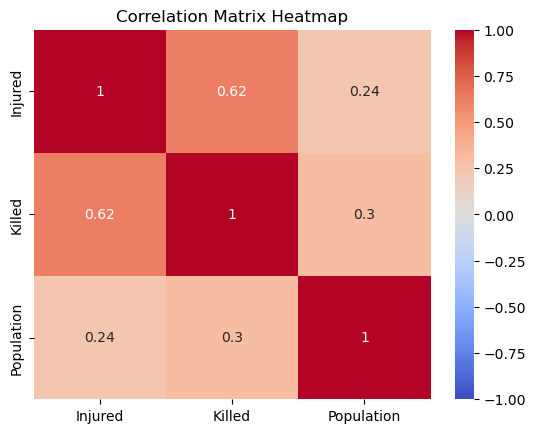

In [11]:
# Generate a heatmap of the correlation matrix of the updated DataFrame, excluding the 'Year' column
import seaborn as sns

# Calculate the correlation matrix
corr = df.corr()

# Generate a heatmap
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix Heatmap')

# Save the plot as a PNG file and an EPS file
plt.savefig('images/correlation_matrix_heatmap.png', format='png', dpi=220)
plt.savefig('images/correlation_matrix_heatmap.eps', format='eps', dpi=220)

# Display the plot
plt.show()

In [12]:
# Find the variance in the number of injured people by year
injured_variance = df['Injured'].var()

# Find the variance in the number of killed people by year
killed_variance = df['Killed'].var()

# Display the variances
print("Variance in the number of injured people by year: {}".format(injured_variance))
print("Variance in the number of killed people by year: {}".format(killed_variance))

# Find the standard deviation in the number of injured people by year
injured_std = df['Injured'].std()

# Find the standard deviation in the number of killed people by year
killed_std = df['Killed'].std()

# Display the standard deviations
print("Standard deviation in the number of injured people by year: {}".format(injured_std))
print("Standard deviation in the number of killed people by year: {}".format(killed_std))

# Find the coefficient of variation for the number of injured people by year
injured_cv = injured_std / df['Injured'].mean()

# Find the coefficient of variation for the number of killed people by year
killed_cv = killed_std / df['Killed'].mean()

# Display the coefficients of variation
print("Coefficient of variation for the number of injured people by year: {:.2f}".format(injured_cv))
print("Coefficient of variation for the number of killed people by year: {:.2f}".format(killed_cv))

# Find the skewness in the number of injured people by year
injured_skewness = df['Injured'].skew()

# Find the skewness in the number of killed people by year
killed_skewness = df['Killed'].skew()

# Display the skewness values
print("Skewness in the number of injured people by year: {:.2f}".format(injured_skewness))
print("Skewness in the number of killed people by year: {:.2f}".format(killed_skewness))

# Find the kurtosis in the number of injured people by year
injured_kurtosis = df['Injured'].kurtosis()

# Find the kurtosis in the number of killed people by year
killed_kurtosis = df['Killed'].kurtosis()

# Display the kurtosis values
print("Kurtosis in the number of injured people by year: {:.2f}".format(injured_kurtosis))
print("Kurtosis in the number of killed people by year: {:.2f}".format(killed_kurtosis))

# Find the covariance between the number of injured and killed people by year
covariance = df['Injured'].cov(df['Killed'])

# Display the covariance
print("Covariance between the number of injured and killed people by year: {:.2f}".format(covariance))

Variance in the number of injured people by year: 94254610.23076923
Variance in the number of killed people by year: 1913.8076923076922
Standard deviation in the number of injured people by year: 9708.481355534925
Standard deviation in the number of killed people by year: 43.74708781516425
Coefficient of variation for the number of injured people by year: 0.19
Coefficient of variation for the number of killed people by year: 0.18
Skewness in the number of injured people by year: -1.37
Skewness in the number of killed people by year: -1.49
Kurtosis in the number of injured people by year: 2.24
Kurtosis in the number of killed people by year: 2.91
Covariance between the number of injured and killed people by year: 263285.45


In [13]:
# Calculating injury and fatality rates per capita (per 100,000 people for better interpretability)
df['Injury Rate per 100k'] = (df['Injured'] / df['Population']) * 100000
df['Fatality Rate per 100k'] = (df['Killed'] / df['Population']) * 100000

# Displaying the updated DataFrame with the injury and fatality rates
df[['Injured', 'Killed', 'Population', 'Injury Rate per 100k', 'Fatality Rate per 100k']]


,Injured,Killed,Population,Injury Rate per 100k,Fatality Rate per 100k
Year,,,,,
2012,27453,137,8361000,328.345892,1.638560
2013,55128,297,8399000,656.363853,3.536135
2014,51226,262,8438000,607.086987,3.105001
2015,51358,243,8468000,606.495040,2.869627
2016,60317,246,8491000,710.363915,2.897185
2017,60656,256,8538000,710.423987,2.998360
2018,61941,231,8531000,726.069628,2.707772
2019,61390,244,8337000,736.356003,2.926712
2020,44614,269,8740000,510.457666,3.077803


In [14]:
from statsmodels.genmod.generalized_linear_model import GLM
from statsmodels.genmod.families import NegativeBinomial
import numpy as np

# Create population projection for 2025-2030 using a linear trend
future_years = np.arange(2025, 2031)
population_trend = np.polyfit(df.index, df['Population'], 1)  # Linear trend
future_population = np.polyval(population_trend, future_years).astype(int)

# Prepare the data for modeling
df['Year'] = df.index  # Add Year as a column for modeling

# Estimate alpha parameter for Negative Binomial distribution
alpha_injured = df['Injured'].var() / df['Injured'].mean()
alpha_killed = df['Killed'].var() / df['Killed'].mean()

# Display the alpha values
print("Estimated alpha for Injured: {:.2f}".format(alpha_injured))
print("Estimated alpha for Killed: {:.2f}".format(alpha_killed))

# Fit Negative Binomial model for Injury Rate
injury_model = GLM(df['Injured'], df[['Year', 'Population']], family=NegativeBinomial(alpha=alpha_injured)).fit()

# Fit Negative Binomial model for Fatality Rate
fatality_model = GLM(df['Killed'], df[['Year', 'Population']], family=NegativeBinomial(alpha=alpha_killed)).fit()

# Create future DataFrame for predictions
future_df = pd.DataFrame({
    'Year': future_years,
    'Population': future_population
})

# Predict the number of injuries and fatalities for 2025-2030 in integers
future_df['Predicted Injured'] = injury_model.predict(future_df[['Year', 'Population']]).astype(int)
future_df['Predicted Killed'] = fatality_model.predict(future_df[['Year', 'Population']]).astype(int)

# Display the prediction results for 2025-2030
future_df[['Year', 'Population', 'Predicted Injured', 'Predicted Killed']].set_index('Year')

Estimated alpha for Injured: 1821.36
Estimated alpha for Killed: 7.66


,Population,Predicted Injured,Predicted Killed
Year,,,
2025,8345884,51671,245
2026,8334439,51670,244
2027,8322994,51669,244
2028,8311549,51668,243
2029,8300104,51667,242
2030,8288659,51667,242


2024-10-27 17:37:46.164586: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 37072688.0000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 3280.4570
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step
Test Loss for Injured Prediction: 37072688.00
Test Loss for Killed Prediction: 3280.46
RMSE for Injured Prediction: 6088.73
RMSE for Killed Prediction: 57.28


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


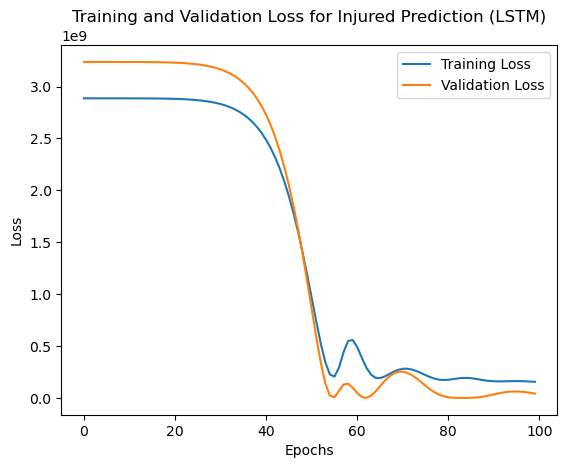

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


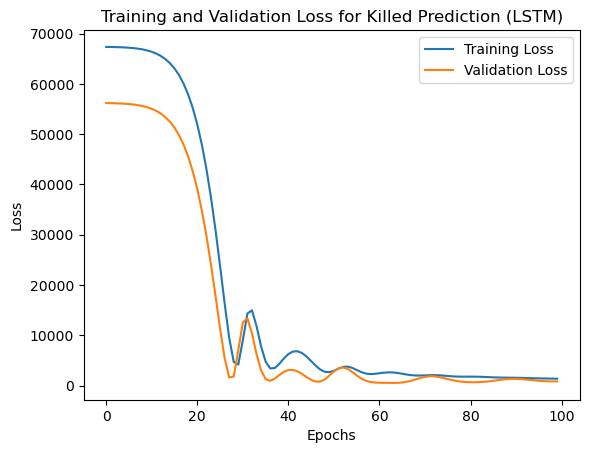

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step


,Population,Predicted Injured,Predicted Killed,Predicted Injured (NN),Predicted Killed (NN)
Year,,,,,
2025,8345884,51671,245,58381,256
2026,8334439,51670,244,59626,259
2027,8322994,51669,244,60872,263
2028,8311549,51668,243,62118,268
2029,8300104,51667,242,63367,273
2030,8288659,51667,242,64618,279


In [15]:
from keras import models
from keras import layers
from keras import optimizers
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error

# Prepare the data for modeling
X = df[['Year', 'Population']]
y_injured = df['Injured']
y_killed = df['Killed']

# Split the data into training and testing sets
X_train, X_test, y_train_injured, y_test_injured = train_test_split(X, y_injured, test_size=0.2, random_state=42)
X_train, X_test, y_train_killed, y_test_killed = train_test_split(X, y_killed, test_size=0.2, random_state=42)

# Scale the data
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Build the neural network model for predicting the number of injured people
model_injured = models.Sequential()
model_injured.add(layers.Dense(1024, activation='relu', input_shape=(X_train.shape[1],)))
model_injured.add(layers.Dense(512, activation='relu'))
model_injured.add(layers.Dense(256, activation='relu'))
model_injured.add(layers.Dense(128, activation='relu'))
model_injured.add(layers.Dense(64, activation='relu'))
model_injured.add(layers.Dense(32, activation='relu'))
model_injured.add(layers.Dense(16, activation='relu'))
model_injured.add(layers.Dense(8, activation='relu'))
model_injured.add(layers.Dense(4, activation='relu'))
model_injured.add(layers.Dense(2, activation='relu'))
model_injured.add(layers.Dense(1))

# Compile the model
model_injured.compile(optimizer=optimizers.Adam(learning_rate=0.001), loss='mean_squared_error')

# Train the model
history_injured = model_injured.fit(X_train_scaled, y_train_injured, epochs=100, batch_size=32, validation_split=0.2, verbose=0)

# Build the neural network model for predicting the number of killed people
model_killed = models.Sequential()
model_killed.add(layers.Dense(1024, activation='relu', input_shape=(X_train.shape[1],)))
model_killed.add(layers.Dense(512, activation='relu'))
model_killed.add(layers.Dense(256, activation='relu'))
model_killed.add(layers.Dense(128, activation='relu'))
model_killed.add(layers.Dense(64, activation='relu'))
model_killed.add(layers.Dense(32, activation='relu'))
model_killed.add(layers.Dense(16, activation='relu'))
model_killed.add(layers.Dense(8, activation='relu'))
model_killed.add(layers.Dense(4, activation='relu'))
model_killed.add(layers.Dense(2, activation='relu'))
model_killed.add(layers.Dense(1))

# Compile the model
# model_injured.compile(optimizer=optimizers.Adam(learning_rate=0.001), loss='mean_squared_error')

# Compile the model
model_killed.compile(optimizer=optimizers.Adam(learning_rate=0.001), loss='mean_squared_error')

# Train the model
history_killed = model_killed.fit(X_train_scaled, y_train_killed, epochs=100, batch_size=32, validation_split=0.2, verbose=0)

# Evaluate the model on the test set
test_loss_injured = model_injured.evaluate(X_test_scaled, y_test_injured)
test_loss_killed = model_killed.evaluate(X_test_scaled, y_test_killed)

# Predict the number of injured and killed people using the trained models
y_pred_injured = model_injured.predict(X_test_scaled).flatten()
y_pred_killed = model_killed.predict(X_test_scaled).flatten()

# Calculate the root mean squared error for the predictions
rmse_injured = root_mean_squared_error(y_test_injured, y_pred_injured)
rmse_killed = root_mean_squared_error(y_test_killed, y_pred_killed)

# Display the test loss and RMSE for the predictions
print("Test Loss for Injured Prediction: {:.2f}".format(test_loss_injured))
print("Test Loss for Killed Prediction: {:.2f}".format(test_loss_killed))

print("RMSE for Injured Prediction: {:.2f}".format(rmse_injured))
print("RMSE for Killed Prediction: {:.2f}".format(rmse_killed))

# Create a DataFrame for the test set predictions
test_results = pd.DataFrame({
    'Year': X_test['Year'],
    'Population': X_test['Population'],
    'Actual Injured': y_test_injured,
    'Predicted Injured': y_pred_injured,
    'Actual Killed': y_test_killed,
    'Predicted Killed': y_pred_killed
})

# Display the test set predictions
test_results.set_index('Year', inplace=True)

# Plot the training and validation loss for the injured prediction model
plt.plot(history_injured.history['loss'], label='Training Loss')
plt.plot(history_injured.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss for Injured Prediction (LSTM)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Save the plot as a PNG file and an EPS file
plt.savefig('images/training_validation_loss_injured.png', format='png', dpi=220)
plt.savefig('images/training_validation_loss_injured.eps', format='eps', dpi=220)

plt.show()

# Plot the training and validation loss for the killed prediction model
plt.plot(history_killed.history['loss'], label='Training Loss')
plt.plot(history_killed.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss for Killed Prediction (LSTM)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Save the plot as a PNG file and an EPS file
plt.savefig('images/training_validation_loss_killed.png', format='png', dpi=220)
plt.savefig('images/training_validation_loss_killed.eps', format='eps', dpi=220)

plt.show()

# Predict the number of injuries and fatalities for 2025-2030 using the trained models
future_df['Predicted Injured (NN)'] = model_injured.predict(scaler.transform(future_df[['Year', 'Population']])).flatten().astype(int)
future_df['Predicted Killed (NN)'] = model_killed.predict(scaler.transform(future_df[['Year', 'Population']])).flatten().astype(int)

# Display the prediction results for 2025-2030
future_df[['Year', 'Population', 'Predicted Injured', 'Predicted Killed', 'Predicted Injured (NN)', 'Predicted Killed (NN)']].set_index('Year')

In [16]:
# import networkx as nx
# import matplotlib.pyplot as plt

# # Define the layer sizes, starting with 1024 and halving each time down to 1
# layers = [1024, 512, 256, 128, 64, 32, 16, 8, 4, 2, 1]

# # Initialize the graph
# G = nx.DiGraph()
# pos = {}
# current_x = 0

# # Create nodes and edges layer by layer
# for layer_index, layer_size in enumerate(layers):
#     for i in range(layer_size):
#         node_id = f"L{layer_index}_{i}"
#         G.add_node(node_id, pos=(current_x, i - layer_size / 2))
#         pos[node_id] = (current_x, i - layer_size / 2)
        
#         # Connect to nodes in the previous layer
#         if layer_index > 0:
#             prev_layer_size = layers[layer_index - 1]
#             for j in range(prev_layer_size):
#                 prev_node_id = f"L{layer_index - 1}_{j}"
#                 G.add_edge(prev_node_id, node_id)
    
#     current_x += 1

# # Draw the graph
# plt.figure(figsize=(12, 12))
# nx.draw(G, pos, with_labels=False, node_size=10, node_color="skyblue", edge_color="gray", alpha=0.5)
# plt.title("Progressive Neural Network Architecture for the LSTM Model")
# plt.show()


In [17]:
# Find MSE, RMSE, MAE, for the predictions with Negative Binomial and Neural Network models
from sklearn.metrics import root_mean_squared_error, mean_absolute_error
from math import sqrt

# Calculate the Root Mean Squared Error (MSE) for the Negative Binomial model predictions
rmse_injured_nb = root_mean_squared_error(y_test_injured, injury_model.predict(X_test_scaled))
rmse_killed_nb = root_mean_squared_error(y_test_killed, fatality_model.predict(X_test_scaled))

# Calculate the Mean Squared Error (RMSE) for the Negative Binomial model predictions
mse_injured_nb = rmse_killed_nb**2
mse_killed_nb = rmse_killed_nb**2

# Calculate the Mean Absolute Error (MAE) for the Negative Binomial model predictions
mae_injured_nb = mean_absolute_error(y_test_injured, injury_model.predict(X_test_scaled))
mae_killed_nb = mean_absolute_error(y_test_killed, fatality_model.predict(X_test_scaled))

# Calculate the Psuedo R-squared for the Negative Binomial model predictions
psuedo_r2_injured_nb = 1 - (np.var(y_test_injured - injury_model.predict(X_test_scaled)) / np.var(y_test_injured))
psuedo_r2_killed_nb = 1 - (np.var(y_test_killed - fatality_model.predict(X_test_scaled)) / np.var(y_test_killed))

# Calculate the Mean Absolute Percentage Error (MAPE) for the Negative Binomial model predictions
mape_injured_nb = np.mean(np.abs((y_test_injured - injury_model.predict(X_test_scaled)) / y_test_injured)) * 100
mape_killed_nb = np.mean(np.abs((y_test_killed - fatality_model.predict(X_test_scaled)) / y_test_killed)) * 100
                                    
# Calculate the Root Mean Squared Error (RMSE) for the Neural Network model predictions
rmse_injured_nn = root_mean_squared_error(y_test_injured, y_pred_injured)
rmse_killed_nn = root_mean_squared_error(y_test_killed, y_pred_killed)

# Calculate the Mean Squared Error (RMSE) for the Neural Network model predictions
mse_injured_nn = rmse_killed_nn**2
mse_killed_nn = rmse_killed_nn**2

# Calculate the Mean Absolute Error (MAE) for the Neural Network model predictions
mae_injured_nn = mean_absolute_error(y_test_injured, y_pred_injured)
mae_killed_nn = mean_absolute_error(y_test_killed, y_pred_killed)

# Calculate the Psuedo R-squared for the Neural Network model predictions
psuedo_r2_injured_nn = 1 - (np.var(y_test_injured - y_pred_injured) / np.var(y_test_injured))
psuedo_r2_killed_nn = 1 - (np.var(y_test_killed - y_pred_killed) / np.var(y_test_killed))

# Calculate the Mean Absolute Percentage Error (MAPE) for the Neural Network model predictions
mape_injured_nn = np.mean(np.abs((y_test_injured - y_pred_injured) / y_test_injured)) * 100
mape_killed_nn = np.mean(np.abs((y_test_killed - y_pred_killed) / y_test_killed)) * 100

# Display the MSE, RMSE, MAE and MAPE for the predictions with Negative Binomial and Neural Network models in a DataFrame with 2 decimal places
error_metrics = pd.DataFrame({
    'Model': ['Negative Binomial', 'Neural Network'],
    'Injured MSE': [round(mse_injured_nb, 2), round(mse_injured_nn, 2)],
    'Injured RMSE': [round(rmse_injured_nb, 2), round(rmse_injured_nn, 2)],
    'Injured MAE': [round(mae_injured_nb, 2), round(mae_injured_nn, 2)],
    'Injured Psuedo R-squared': [round(psuedo_r2_injured_nb, 2), round(psuedo_r2_injured_nn, 2)],
    'Injured MAPE (%)': [round(mape_injured_nb, 2), round(mape_injured_nn, 2)],
    'Killed MSE': [round(mse_killed_nb, 2), round(mse_killed_nn, 2)],
    'Killed RMSE': [round(rmse_killed_nb, 2), round(rmse_killed_nn, 2)],
    'Killed MAE': [round(mae_killed_nb, 2), round(mae_killed_nn, 2)],
    'Killed Psuedo R-squared': [round(psuedo_r2_killed_nb, 2), round(psuedo_r2_killed_nn, 2)],
    'Killed MAPE (%)': [round(mape_killed_nb, 2), round(mape_killed_nn, 2)]
})


# Display the error metrics
error_metrics


,Model,Injured MSE,Injured RMSE,Injured MAE,Injured Psuedo R-squared,Injured MAPE (%),Killed MSE,Killed RMSE,Killed MAE,Killed Psuedo R-squared,Killed MAPE (%)
0,Negative Binomial,60578.59,46108.73,44494.66,0.00,100.00,60578.59,246.13,235.67,0.00,99.52
1,Neural Network,3280.46,6088.73,5578.68,0.83,15.76,3280.46,57.28,53.97,0.35,28.95


In [18]:
# Calculate AIC and BIC for the Negative Binomial models using the log-likelihood, number of parameters, and sample size
n = len(df)
ll_injured = injury_model.llf
ll_killed = fatality_model.llf
k_injured = injury_model.df_model
k_killed = fatality_model.df_model

# Calculate AIC for the Negative Binomial models
aic_injured = -2 * ll_injured + 2 * k_injured
aic_killed = -2 * ll_killed + 2 * k_killed

# Calculate BIC for the Negative Binomial models
bic_injured = -2 * ll_injured + k_injured * np.log(n)
bic_killed = -2 * ll_killed + k_killed * np.log(n)
      
# Calculate AIC and BIC for the Neural Network models using the log-likelihood, number of parameters, and sample size
n = len(X_test)
ll_injured_nn = -0.5 * n * np.log(2 * np.pi) - 0.5 * n * np.log(rmse_injured_nn**2) - n / 2
ll_killed_nn = -0.5 * n * np.log(2 * np.pi) - 0.5 * n * np.log(rmse_killed_nn**2) - n / 2
k_injured_nn = len(model_injured.get_weights())
k_killed_nn = len(model_killed.get_weights())

# Calculate AIC for the Neural Network models
aic_injured_nn = -2 * ll_injured_nn + 2 * k_injured_nn
aic_killed_nn = -2 * ll_killed_nn + 2 * k_killed_nn

# Calculate BIC for the Neural Network models
bic_injured_nn = -2 * ll_injured_nn + k_injured_nn * np.log(n)
bic_killed_nn = -2 * ll_killed_nn + k_killed_nn * np.log(n)

# Display the AIC and BIC values for the Negative Binomial and Neural Network models in a DataFrame
aic_bic = pd.DataFrame({
    'Model': ['Negative Binomial (Injured)', 'Negative Binomial (Killed)', 'Neural Network (Injured)', 'Neural Network (Killed)'],
    'AIC': [round(aic_injured, 2), round(aic_killed, 2), round(aic_injured_nn, 2), round(aic_killed_nn, 2)],
    'BIC': [round(bic_injured, 2), round(bic_killed, 2), round(bic_injured_nn, 2), round(bic_killed_nn, 2)]
})

# Display the AIC and BIC values
aic_bic.set_index('Model')

,AIC,BIC
Model,,
Negative Binomial (Injured),478.99,479.55
Negative Binomial (Killed),206.77,207.34
Neural Network (Injured),104.80,84.97
Neural Network (Killed),76.80,56.97


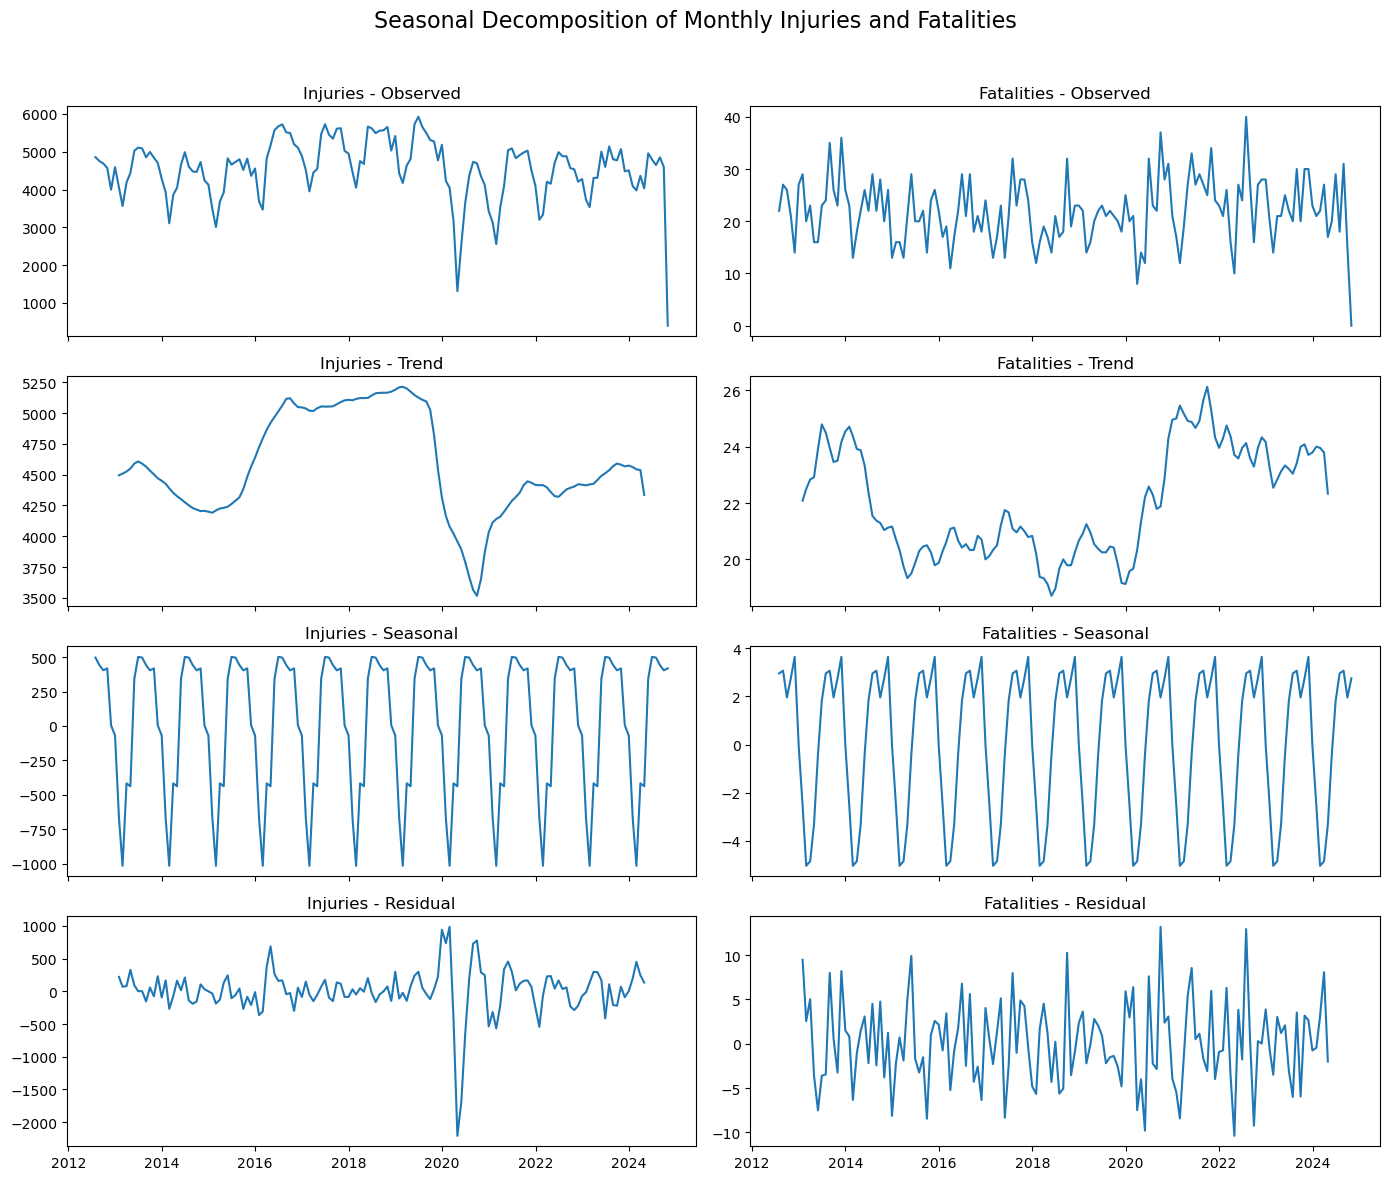

In [19]:
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# Initialize an empty DataFrame to accumulate monthly counts
monthly_data_combined = pd.DataFrame(columns=['NUMBER OF PERSONS INJURED', 'NUMBER OF PERSONS KILLED'])

# Define file path and chunk size
file_path = 'new_dataset.csv'
chunk_size = 50000  # Adjust chunk size based on memory capacity

# Process the dataset in chunks
for chunk in pd.read_csv(file_path, usecols=['CRASH DATE', 'NUMBER OF PERSONS INJURED', 'NUMBER OF PERSONS KILLED'], 
                         chunksize=chunk_size, parse_dates=['CRASH DATE'], infer_datetime_format=True):
    # Drop rows with invalid dates if any
    chunk = chunk.dropna(subset=['CRASH DATE'])
    
    # Convert injury and fatality counts to integers, filling any NaNs with 0
    chunk['NUMBER OF PERSONS INJURED'] = chunk['NUMBER OF PERSONS INJURED'].fillna(0).astype(int)
    chunk['NUMBER OF PERSONS KILLED'] = chunk['NUMBER OF PERSONS KILLED'].fillna(0).astype(int)
    
    # Resample to monthly frequency within the chunk, summing injuries and fatalities
    monthly_chunk = chunk.resample('M', on='CRASH DATE').agg({
        'NUMBER OF PERSONS INJURED': 'sum',
        'NUMBER OF PERSONS KILLED': 'sum'
    })
    
    # Accumulate monthly counts
    monthly_data_combined = monthly_data_combined.add(monthly_chunk, fill_value=0)

# Ensure the index is datetime format
monthly_data_combined.index = pd.to_datetime(monthly_data_combined.index)

# Perform seasonal decomposition on the aggregated monthly data
decomposition_injured = seasonal_decompose(monthly_data_combined['NUMBER OF PERSONS INJURED'], model='additive', period=12)
decomposition_killed = seasonal_decompose(monthly_data_combined['NUMBER OF PERSONS KILLED'], model='additive', period=12)

# Plot the decomposition results for injuries and fatalities on a single canvas
fig, axs = plt.subplots(4, 2, figsize=(14, 12), sharex=True)

# Plot decomposition for injuries
axs[0, 0].plot(decomposition_injured.observed)
axs[0, 0].set_title("Injuries - Observed")
axs[1, 0].plot(decomposition_injured.trend)
axs[1, 0].set_title("Injuries - Trend")
axs[2, 0].plot(decomposition_injured.seasonal)
axs[2, 0].set_title("Injuries - Seasonal")
axs[3, 0].plot(decomposition_injured.resid)
axs[3, 0].set_title("Injuries - Residual")

# Plot decomposition for fatalities
axs[0, 1].plot(decomposition_killed.observed)
axs[0, 1].set_title("Fatalities - Observed")
axs[1, 1].plot(decomposition_killed.trend)
axs[1, 1].set_title("Fatalities - Trend")
axs[2, 1].plot(decomposition_killed.seasonal)
axs[2, 1].set_title("Fatalities - Seasonal")
axs[3, 1].plot(decomposition_killed.resid)
axs[3, 1].set_title("Fatalities - Residual")

# Add a main title for the figure
fig.suptitle('Seasonal Decomposition of Monthly Injuries and Fatalities', fontsize=16)

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust rect to make room for the main title

# Save the plot as a PNG file and an EPS file
plt.savefig('images/seasonal_decomposition.png', format='png', dpi=220)
plt.savefig('images/seasonal_decomposition.eps', format='eps', dpi=220)

# Display the plot
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


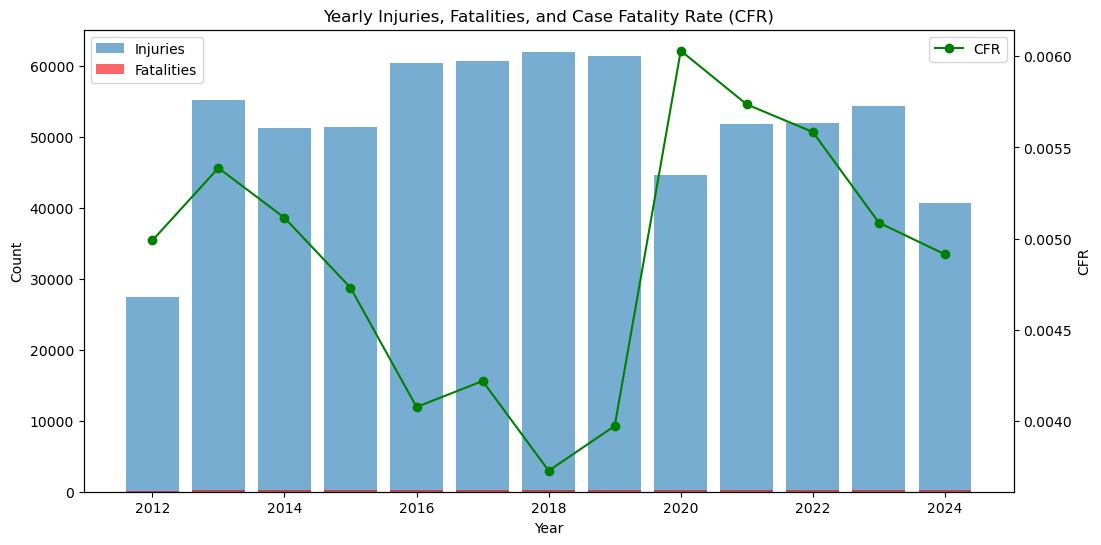

In [26]:
import matplotlib.pyplot as plt

# Create a figure and axis
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Injuries and Fatalities as bar plots
ax1.bar(df.index, df['Injured'], alpha=0.6, label='Injuries')
ax1.bar(df.index, df['Killed'], color='r', alpha=0.6, label='Fatalities')

# Set the labels and title
ax1.set_xlabel('Year')
ax1.set_ylabel('Count')
ax1.set_title('Yearly Injuries, Fatalities, and Case Fatality Rate (CFR)')

# Create a second y-axis for the CFR
ax2 = ax1.twinx()
ax2.plot(df.index, df['Killed'] / df['Injured'], color='g', marker='o', linestyle='-', label='CFR')

# Set the label for the second y-axis
ax2.set_ylabel('CFR')

# Add legends
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

# Save the plot as a PNG file and an EPS file
plt.savefig('images/injuries_fatalities_cfr.png', format='png', dpi=220)
plt.savefig('images/injuries_fatalities_cfr.eps', format='eps', dpi=220)

# Show the plot
plt.show()